Информация о метриках

| Признак    | Описание                                       |
| ---------- | ---------------------------------------------- |
| `Pclass`   | Класс обслуживания                             |
| `Sex`      | Пол пассажира                                  |
| `Age`      | Возраст                                        |
| `SibSp`    | Количество братьев, сестёр и супругов на борту |
| `Parch`    | Количество родителей и детей на борту          |
| `Ticket`   | Номер билета                                   |
| `Fare`     | Стоимость проезда                              |
| `Cabin`    | Номер кабины                                   |
| `Embarked` | Порт посадки                                   |

In [238]:
import pandas as pd

In [239]:
df = pd.read_csv("E:/ML/titanic-ml/data/raw/train.csv")

## Постановка FE-гипотез

In [240]:
df['Age']

0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888     NaN
889    26.0
890    32.0
Name: Age, Length: 891, dtype: float64

Для `Age` можно создать категориальный признак, соответствующий возрастной группе пассажира. Например, отдельный бинарный признак `Child`, равный 1 для пассажиров младше определённого возраста. В качестве возможных порогов можно рассмотреть 10, 15 и 18 лет и проверить их влияние на качество модели. Гипотеза основана на предположении, что возрастная группа пассажира может влиять на вероятность выживания.

In [241]:
df['Name']

0                                Braund, Mr. Owen Harris
1      Cumings, Mrs. John Bradley (Florence Briggs Th...
2                                 Heikkinen, Miss. Laina
3           Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                               Allen, Mr. William Henry
                             ...                        
886                                Montvila, Rev. Juozas
887                         Graham, Miss. Margaret Edith
888             Johnston, Miss. Catherine Helen "Carrie"
889                                Behr, Mr. Karl Howell
890                                  Dooley, Mr. Patrick
Name: Name, Length: 891, dtype: str

Как видно из датасета признак `Name` строится по следующему шаблону: [Фамилия] + [Статус/обращение] + [Имя]  
Фамилия можеть информировать о составе семьи, а как мы видим на eda при анализе `SibSp` и `Parch`, количество родственников на борту может влиять на вероятность выживания  

Статус/обращение `Title` может содержать информацию о поле, возрасте, семейном положении и социальном статусе пассажира. Поэтому можно извлечь `Title` из `Name` и исследовать его влияние на вероятность выживания. Редкие обращения при необходимости можно объединить в отдельную категорию. 
Само имя пассажира, вероятно, не содержит значимой информации для классификации и не требует отдельного использования.

Признаки `SibSp` и `Parch` характеризуют наличие родственников на борту. Их можно объединить в новый признак `FamilySize`, рассчитываемый как сумма `SibSp`, `Parch` и самого пассажира. Дополнительно можно рассмотреть бинарный признак `IsAlone`, указывающий, путешествовал ли пассажир один.

In [242]:
df['Cabin']

0       NaN
1       C85
2       NaN
3      C123
4       NaN
       ... 
886     NaN
887     B42
888     NaN
889    C148
890     NaN
Name: Cabin, Length: 891, dtype: str

Признак `Cabin` также может содержать полезную информацию, наличие или отсутствие информации можно использовать как отдельный признак `HasCabin`.  
Номер каюты состоит из буквенного обозначения палубы и числового номера. Буквенное обозначение можно выделить в признак `Deck`. Числовую часть можно выделить в `CabinNumber`.

## Создание новых признаков

In [243]:
df['Child'] = (df['Age'] < 16).astype(int)

df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

df['isAlone'] = (df['FamilySize'] == 1).astype(int)

df['Deck'] = df['Cabin'].str[0]

df['Title'] = df['Name'].str.extract(r',\s*([^.]+)\.')[0]

df['CabinNumber'] = df['Cabin'].str.extract(r'(\d+)')

df['CabinNumber'] = pd.to_numeric(df['CabinNumber'])

In [244]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Child,FamilySize,isAlone,Deck,Title,CabinNumber
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,0,2,0,NaN,Mr,NaN
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,0,2,0,C,Mrs,85.0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0,1,1,NaN,Miss,NaN
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,0,2,0,C,Mrs,123.0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,0,1,1,NaN,Mr,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,0,1,1,NaN,Rev,NaN
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,0,1,1,B,Miss,42.0
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,0,4,0,NaN,Miss,NaN
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,0,1,1,C,Mr,148.0


In [245]:
new_features = ['Child', 'FamilySize', 'isAlone', 'Deck', 'Title', 'CabinNumber']

In [246]:
df_new = df[new_features]

## EDA для новых признаков

In [247]:
df_new.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Child        891 non-null    int64  
 1   FamilySize   891 non-null    int64  
 2   isAlone      891 non-null    int64  
 3   Deck         204 non-null    str    
 4   Title        891 non-null    str    
 5   CabinNumber  200 non-null    float64
dtypes: float64(1), int64(3), str(2)
memory usage: 41.9 KB


In [248]:
df_new.nunique()

Child           2
FamilySize      9
isAlone         2
Deck            8
Title          17
CabinNumber    92
dtype: int64

In [ ]:
num_features = ['FamilySize', 'CabinNumber']
cat_features = ['Child', 'isAlone', 'Deck', 'Title']

In [250]:
df_new.isna().mean() * 100

Child           0.000000
FamilySize      0.000000
isAlone         0.000000
Deck           77.104377
Title           0.000000
CabinNumber    77.553311
dtype: float64

### Анализ числовых признаков

In [251]:
import matplotlib.pyplot as plt
import seaborn as sns

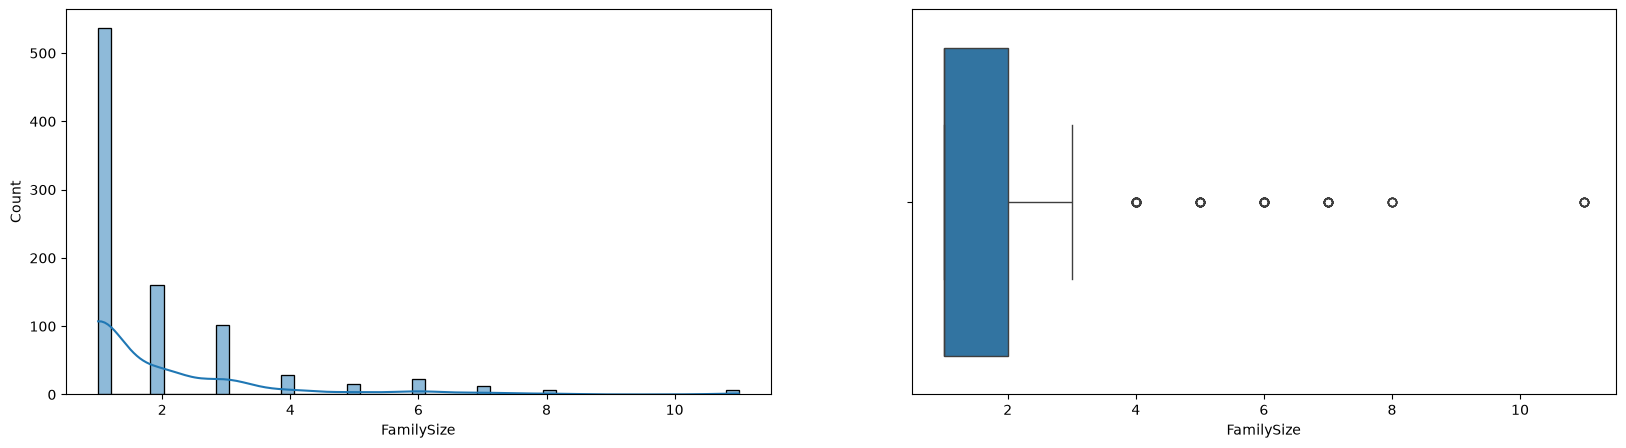

count    891.000000
mean       1.904602
std        1.613459
min        1.000000
25%        1.000000
50%        1.000000
75%        2.000000
max       11.000000
Name: FamilySize, dtype: float64


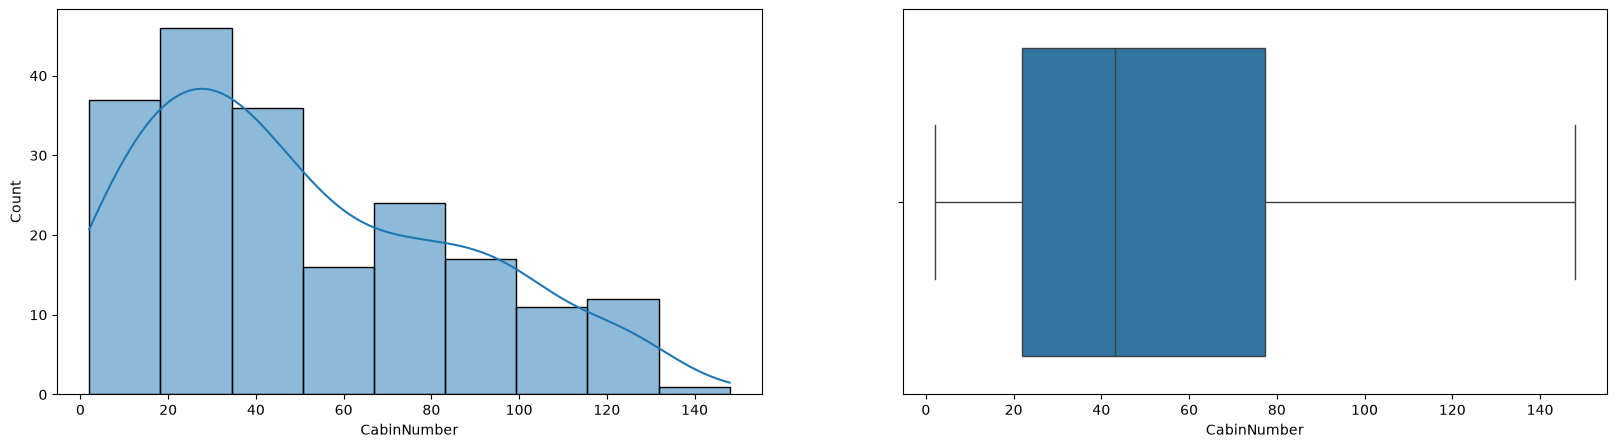

count    200.00000
mean      50.49000
std       35.39497
min        2.00000
25%       22.00000
50%       43.00000
75%       77.25000
max      148.00000
Name: CabinNumber, dtype: float64


In [252]:
def analysis_of_numerical_features(col):
    
    plt.figure(figsize=(20, 5))
    plt.subplot(1, 2, 1)
    sns.histplot(
        data=df_new, 
        x=col, 
        kde=True)

    plt.subplot(1, 2, 2)
    sns.boxplot(
        data=df_new, 
        x=col); 
    plt.show()

    print(df_new[col].describe())

for feature in num_features:
    analysis_of_numerical_features(feature)


**Связь между числовыми признаками**

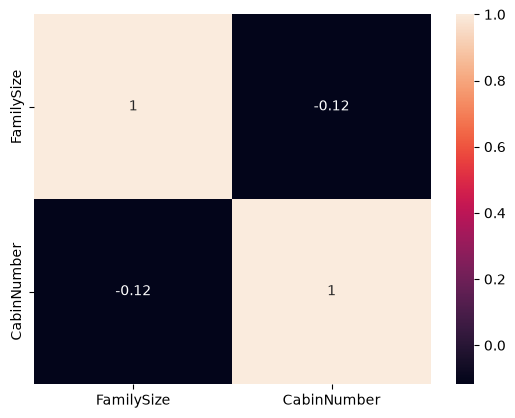

In [253]:
plt.figure()
sns.heatmap(
    df_new[num_features].corr(),
    annot=True
)
plt.show()

Если взять все числовые

In [254]:
old_num_features = ['Age', 'Fare', 'SibSp', 'Parch']

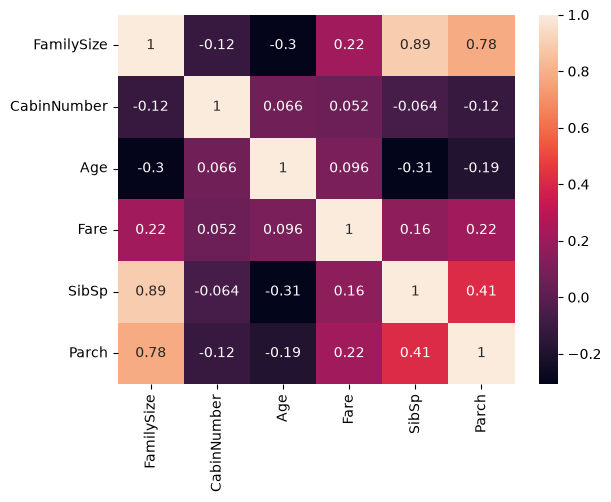

In [255]:
plt.figure()
sns.heatmap(
    df[num_features + old_num_features].corr(),
    annot=True
)
plt.show()

`FimilySize` ожидаемо коррелирует с `SibSp` и `Parch`

**Связь числовых признаков и целевой переменной**

In [256]:
target = 'Survived'

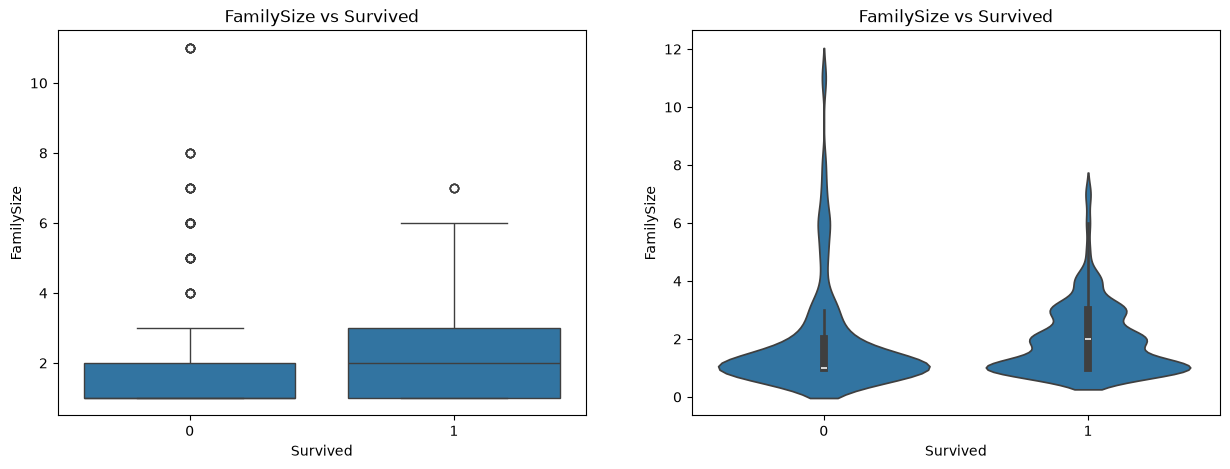

          count      mean       std  min  25%  50%  75%   max
Survived                                                     
0         549.0  1.883424  1.830669  1.0  1.0  1.0  2.0  11.0
1         342.0  1.938596  1.186076  1.0  1.0  2.0  3.0   7.0


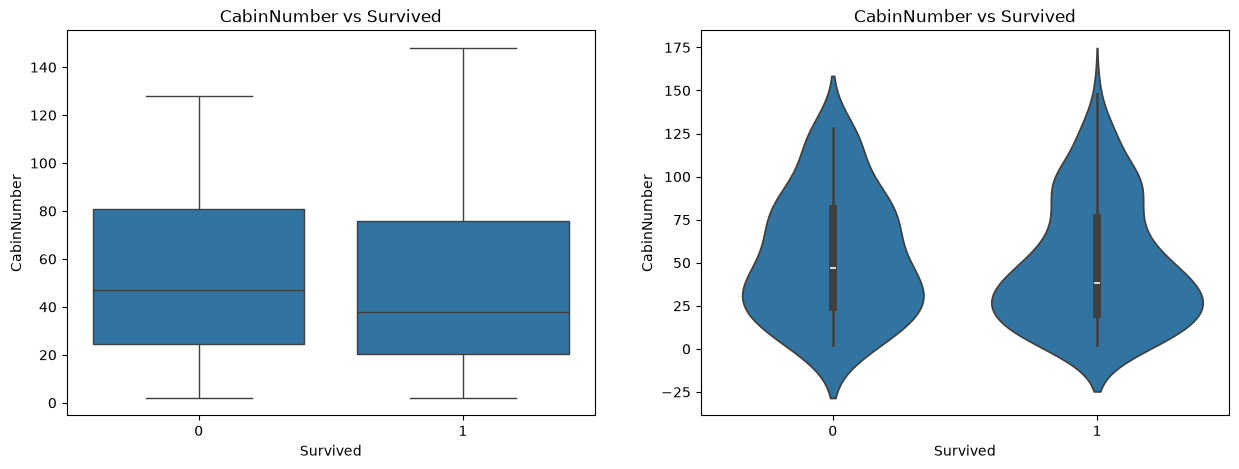

          count       mean        std  min    25%   50%   75%    max
Survived                                                            
0          66.0  53.696970  35.232402  2.0  24.50  47.0  81.0  128.0
1         134.0  48.910448  35.499542  2.0  20.25  38.0  76.0  148.0


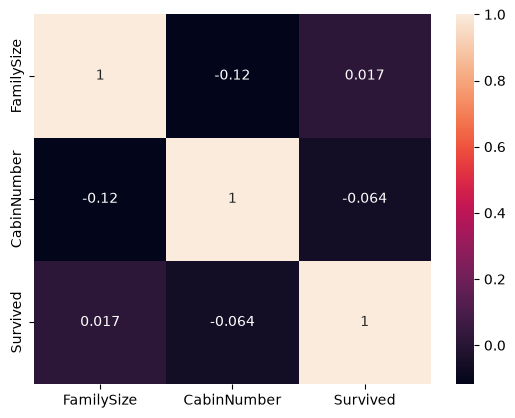

In [257]:
def num_features_target(col):

    plt.figure(figsize=(15, 5))
    plt.subplot(1, 2, 1)
    sns.boxplot(
        data=df,
        x=target,
        y=col
    )
    plt.title(f'{col} vs {target}')

    plt.subplot(1, 2, 2)
    sns.violinplot(
        data=df,
        x=target,
        y=col
    )
    
    plt.title(f'{col} vs {target}')
    plt.show()

    print(df.groupby(target)[col].describe())

for feature in num_features:
    num_features_target(feature)

plt.figure()
sns.heatmap(df[num_features + [target]].corr(),
            annot=True
)
plt.show()

Есть небольшая разница между средними/медианными значениями для новых признаков и значениями таргета.  
Линейная связь с таргетом отсутствует

### Анализ категориальных признаков

Child
0    0.906846
1    0.093154
Name: proportion, dtype: float64


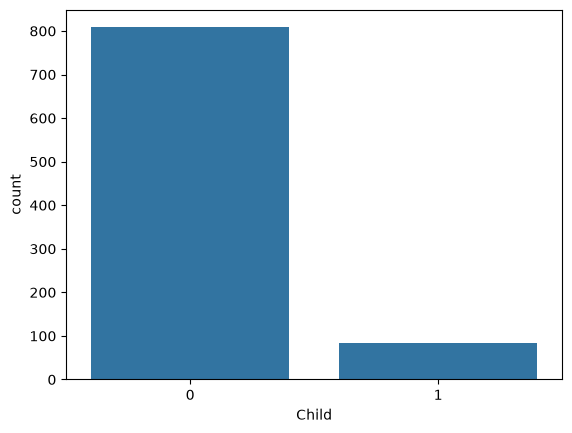

isAlone
1    0.602694
0    0.397306
Name: proportion, dtype: float64


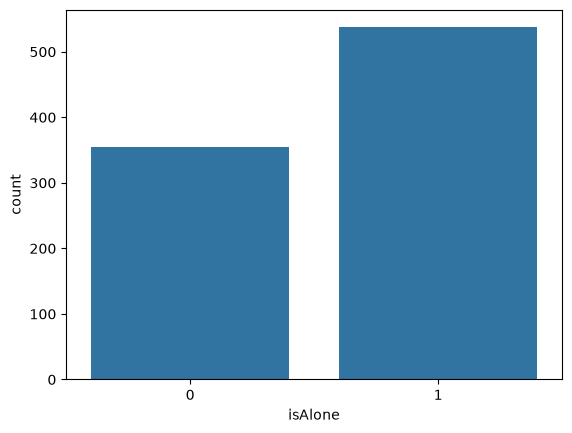

Deck
C    0.289216
B    0.230392
D    0.161765
E    0.156863
A    0.073529
F    0.063725
G    0.019608
T    0.004902
Name: proportion, dtype: float64


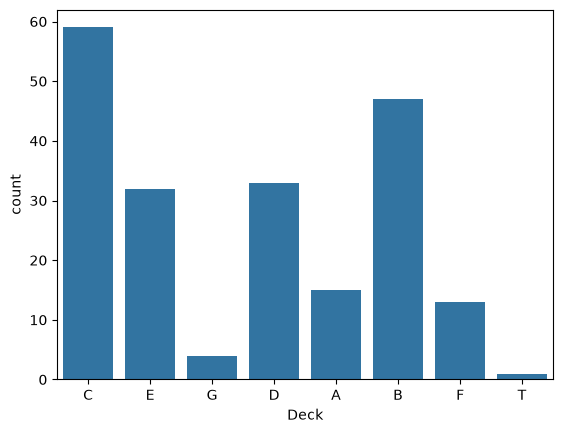

Title
Mr              0.580247
Miss            0.204265
Mrs             0.140292
Master          0.044893
Dr              0.007856
Rev             0.006734
Major           0.002245
Mlle            0.002245
Col             0.002245
Don             0.001122
Mme             0.001122
Ms              0.001122
Lady            0.001122
Sir             0.001122
Capt            0.001122
the Countess    0.001122
Jonkheer        0.001122
Name: proportion, dtype: float64


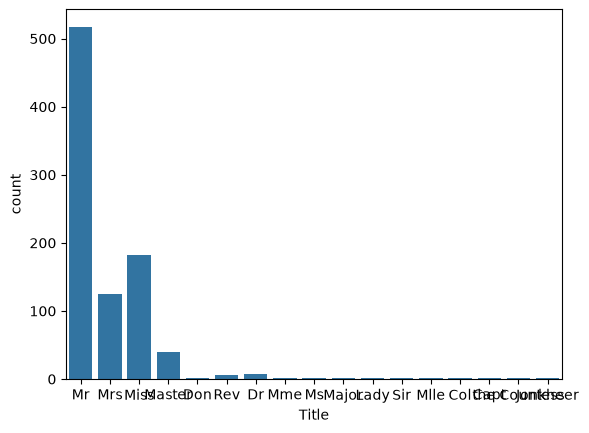

In [258]:
def analysis_of_categorical_features(col):
    
    print(df_new[col].value_counts(normalize=True))
    
    plt.figure()
    sns.countplot(
        data=df_new, 
        x=col)
    plt.show()
 
for feature in cat_features:
    analysis_of_categorical_features(feature)

**Связь между категориальными признаками**

In [259]:
from itertools import combinations
from scipy.stats import chi2_contingency
import numpy as np

In [260]:
old_cat_features = ['Sex', 'Embarked', 'Pclass']

In [261]:
for feature_1, feature_2 in combinations(cat_features + old_cat_features, 2):

    table = pd.crosstab(
        df[feature_1],
        df[feature_2]
    )

    chi2, p_value, dof, expected = chi2_contingency(table)

    n = table.to_numpy().sum()
    min_dim = min(table.shape) - 1

    cramers_v = np.sqrt(
        chi2 / (n * min_dim)
    )

    print(f'\n{feature_1} × {feature_2}')
    print(f'χ² = {chi2:.3f}')
    print(f'p-value = {p_value:.4f}')
    print(f"Cramér's V = {cramers_v:.3f}")

    display(table)


Child × isAlone
χ² = 105.103
p-value = 0.0000
Cramér's V = 0.343


isAlone,0,1
Child,,
0,277,531
1,77,6



Child × Deck
χ² = 29.491
p-value = 0.0001
Cramér's V = 0.380


Deck,A,B,C,D,E,F,G,T
Child,,,,,,,,
0,14,44,57,33,31,9,2,1
1,1,3,2,0,1,4,2,0



Child × Title
χ² = 402.095
p-value = 0.0000
Cramér's V = 0.672


...

Embarked,C,Q,S
Sex,,,
female,73,36,203
male,95,41,441



Sex × Pclass
χ² = 16.971
p-value = 0.0002
Cramér's V = 0.138


Pclass,1,2,3
Sex,,,
female,94,76,144
male,122,108,347



Embarked × Pclass
χ² = 123.752
p-value = 0.0000
Cramér's V = 0.264


Pclass,1,2,3
Embarked,,,
C,85,17,66
Q,2,3,72
S,127,164,353



Child × Survived
χ² = 15.557
p-value = 0.0001
Cramér's V = 0.132


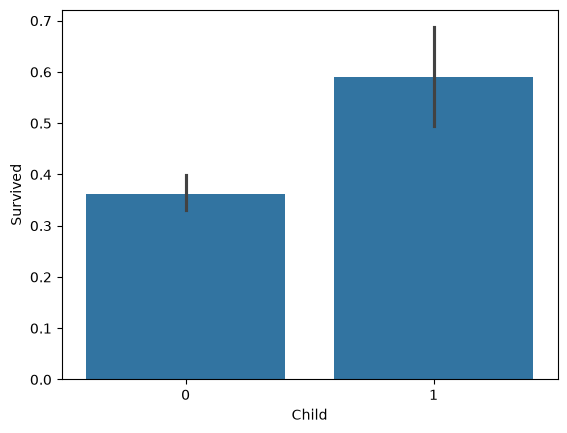

Survived,0,1
Child,,
0,515,293
1,34,49



isAlone × Survived
χ² = 36.001
p-value = 0.0000
Cramér's V = 0.201


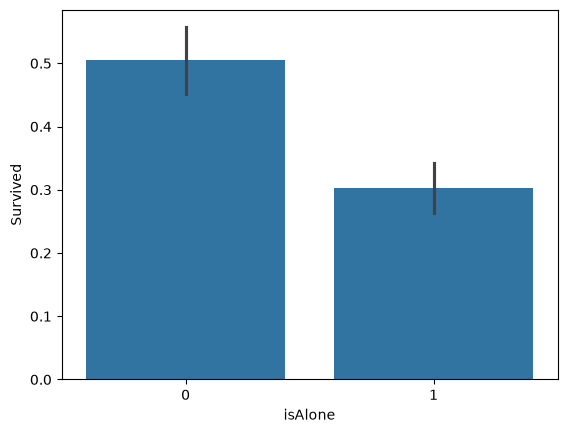

Survived,0,1
isAlone,,
0,175,179
1,374,163



Deck × Survived
χ² = 10.301
p-value = 0.1722
Cramér's V = 0.225


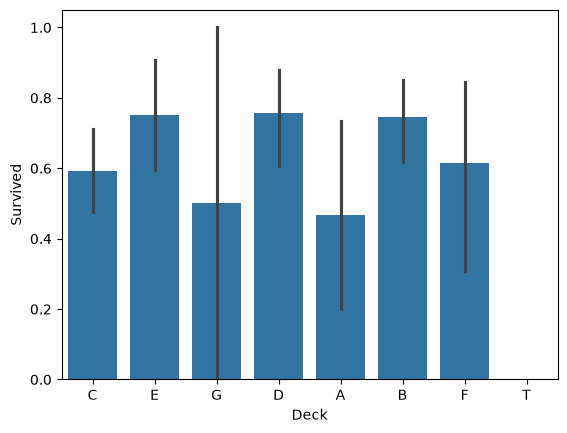

Survived,0,1
Deck,,
A,8,7
B,12,35
C,24,35
D,8,25
E,8,24
F,5,8
G,2,2
T,1,0



Title × Survived
χ² = 300.023
p-value = 0.0000
Cramér's V = 0.580


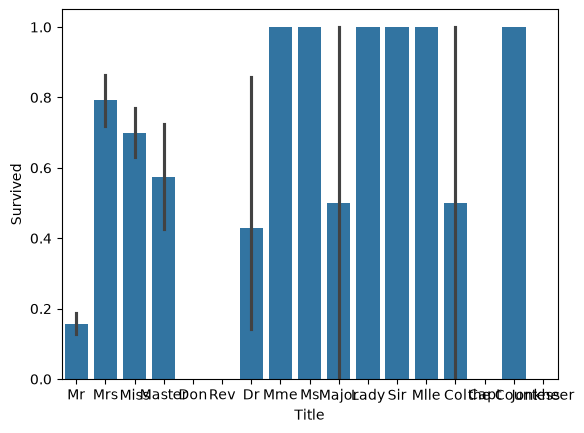

Survived,0,1
Title,,
Capt,1,0
Col,1,1
Don,1,0
Dr,4,3
Jonkheer,1,0
Lady,0,1
Major,1,1
Master,17,23
Miss,55,127


In [262]:
for feature in cat_features:

    table = pd.crosstab(
        df[feature],
        df[target]
    )

    chi2, p_value, dof, expected = chi2_contingency(table)

    n = table.to_numpy().sum()
    min_dim = min(table.shape) - 1

    cramers_v = np.sqrt(
        chi2 / (n * min_dim)
    )

    print(f'\n{feature} × {target}')

    print(f'χ² = {chi2:.3f}')
    print(f'p-value = {p_value:.4f}')
    print(f"Cramér's V = {cramers_v:.3f}")

    plt.figure()
    sns.barplot(
        data=df,
        x=feature,
        y=target
    )
    plt.show()



    display(table)

## Сравнение с Итоговой моделью

In [263]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer   
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate

from sklearn.svm import SVC

In [264]:
y = df['Survived']
X = df.drop(columns='Survived')

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size=0.2,
    shuffle=True,
    random_state=42,
    stratify=y
)

In [291]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

log_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('log', FunctionTransformer(np.log1p)),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first'))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, ['Age', 'SibSp', 'Parch', 'Pclass']),
    ('log', log_pipeline, ['Fare']),
    ('cat', cat_pipeline, ['Sex', 'Embarked'])
])

model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', SVC(
        kernel='linear',
        gamma='auto',
        C=0.1623776739188721
    ))
])

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

cv_results = cross_validate(
    model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)

for metric in scoring:
    scores = cv_results[f'test_{metric}']
    print(
        f'{metric}: '
        f'{scores.mean():.3f} ± {scores.std():.3f}'
    )

accuracy: 0.791 ± 0.091
precision: 0.751 ± 0.131
recall: 0.658 ± 0.167
f1: 0.699 ± 0.148
roc_auc: 0.824 ± 0.099


**Результаты итоговой модели**

Для того, чтобы избежать проблем, свзязанных с мультиколлениарностью воспользуемся не базовой моделью а **Random Forest**, вошедшую в топ-3 модели на этапе моделирования

In [269]:
from sklearn.ensemble import RandomForestClassifier

In [270]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=300,
        min_samples_split=5,
        min_samples_leaf=1,
        max_depth=5,
        random_state=42
    ))
])

In [271]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

In [272]:
cv_results_base = cross_validate(
    model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)

for metric in scoring:
    scores_base = cv_results_base[f'test_{metric}']
    print(
        f'{metric}: '
        f'{scores_base.mean():.3f} ± {scores_base.std():.3f}'
    )

accuracy: 0.741 ± 0.060
precision: 0.706 ± 0.123
recall: 0.587 ± 0.152
f1: 0.626 ± 0.098
roc_auc: 0.836 ± 0.089


### Создадим пайплайн с новыми признаками

In [289]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

log_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('log', FunctionTransformer(np.log1p)),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first',
                              handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, ['Age', 'SibSp', 'Parch', 'Pclass', 'FamilySize']),
    ('log', log_pipeline, ['Fare']),
    ('cat', cat_pipeline, ['Sex', 'Embarked'])
])

model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=300,
        min_samples_split=5,
        min_samples_leaf=1,
        max_depth=5,
        random_state=42
    ))
])

cv_results_fe = cross_validate(
    model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)

for metric in scoring:
    scores_base = cv_results_base[f'test_{metric}']
    scores_fe = cv_results_fe[f'test_{metric}']

    print(
        f'{metric}: '
        f'{scores_base.mean():.3f} → '
        f'{scores_fe.mean():.3f} '
        f'({scores_fe.mean() - scores_base.mean():+.3f})'
    )

accuracy: 0.741 → 0.769 (+0.028)
precision: 0.706 → 0.730 (+0.024)
recall: 0.587 → 0.645 (+0.058)
f1: 0.626 → 0.676 (+0.049)
roc_auc: 0.836 → 0.831 (-0.005)


'FamilySize' +  
'CabinNumber' +  
'Child' -  
'isAlone' -  
'Deck' -  
'Title' -


In [305]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

log_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('log', FunctionTransformer(np.log1p)),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first',
                              handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, ['Age', 'SibSp', 'Parch', 'Pclass', 'FamilySize']),
    ('log', log_pipeline, ['Fare']),
    ('cat', cat_pipeline, ['Sex', 'Embarked', 'isAlone'])
])

model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', SVC(
        kernel='linear',
        gamma='auto',
        C=0.1623776739188721
    ))
])

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

cv_results = cross_validate(
    model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)

for metric in scoring:
    scores = cv_results[f'test_{metric}']
    print(
        f'{metric}: '
        f'{scores.mean():.3f} ± {scores.std():.3f}'
    )

accuracy: 0.791 ± 0.091
precision: 0.751 ± 0.131
recall: 0.658 ± 0.167
f1: 0.699 ± 0.148
roc_auc: 0.830 ± 0.086


In [312]:
y = df['Survived']
X = df.drop(columns='Survived')

model.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](17,)","['PassengerId','Pclass','Name',...,'Deck','Title','CabinNumber']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,17
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('log', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, a

In [313]:
test = pd.read_csv('E:/ML/titanic-ml/data/raw/test.csv')

test['FamilySize'] = test['SibSp'] + test['Parch'] + 1

test['isAlone'] = (test['FamilySize'] == 1).astype(int)

predictions = model.predict(test)

submission = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Survived': predictions
})

submission.to_csv(
    'E:/ML/titanic-ml/data/results/submission.csv',
    index=False
)

## Итоговые выводы
